<a href="https://colab.research.google.com/github/ummuqoshiroh/Prediksi-Harga-Jual-Mobil-Bekas-dengan-Linear-Regression-PrakUTSDataMining/blob/main/UTS_PRAKTIKUM_DAMIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS PRAKTIKUM DATA MINING


Nama: Ummu Qoshiroh Nur Azziza

NPM: 2310631170055

Kelas: 5A - Informatika

# IMPORT LIBRARY

In [ ]:
# import library basic
import pandas as pd
import numpy as np

# visualisai
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns


# LOAD DATASET

In [ ]:
# sumber dataset dari github aslab
!wget https://raw.githubusercontent.com/FarrelllAdityaaa/dataset-uts-datamining/refs/heads/main/used_cars_price_fiks.csv -O used_cars_price_fiks.csv
df = pd.read_csv('used_cars_price_fiks.csv')


--2025-10-06 02:45:23--  https://raw.githubusercontent.com/FarrelllAdityaaa/dataset-uts-datamining/refs/heads/main/used_cars_price_fiks.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 602640 (589K) [text/plain]
Saving to: ‘used_cars_price_fiks.csv’

used_cars_price_fik 100%[===================>] 588.52K  --.-KB/s    in 0.04s   

2025-10-06 02:45:24 (15.2 MB/s) - ‘used_cars_price_fiks.csv’ saved [602640/602640]



penjelasan:
upload dataset berhasil dengan menggunakan printah **wget** dan diberi nama used_cars_price_fiks.csv.

In [ ]:
print("Jumlah baris & kolom:", df.shape) #melihat jumlah baris dan kolom
df.head() #nemapilkan 5 data teratas

Jumlah baris & kolom: (6019, 13)


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000.0,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,2,Honda Jazz V,Chennai,2011,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74


# DATA PROFILING

In [ ]:
print("\n=== Informasi Dataset ===")
df.info() # menampilkan informasi dataset


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  5719 non-null   float64
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   float64
 9   Engine             5983 non-null   float64
 10  Power              5876 non-null   float64
 11  Seats              5977 non-null   float64
 12  Price              6019 non-null   float64
dtypes: float64(6), int64(2), object(5)
memory usage: 611.4+ KB


In [ ]:
print("\n=== Statistik Deskriptif ===")
display(df.describe())


=== Statistik Deskriptif ===


,Unnamed: 0,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,6019.000000,6019.000000,5719.000000,6017.000000,5983.000000,5876.000000,5977.000000,6019.000000
mean,3009.000000,2013.358199,57545.592586,18.134961,1621.276450,113.253050,5.278735,9.479468
std,1737.679967,3.269742,37988.496154,4.582289,601.355233,53.874957,0.808840,11.187917
min,0.000000,1998.000000,171.000000,0.000000,72.000000,34.200000,0.000000,0.440000
25%,1504.500000,2011.000000,33923.000000,15.170000,1198.000000,75.000000,5.000000,3.500000
50%,3009.000000,2014.000000,53000.000000,18.150000,1493.000000,97.700000,5.000000,5.640000
75%,4513.500000,2016.000000,72998.000000,21.100000,1984.000000,138.100000,5.000000,9.950000
max,6018.000000,2019.000000,775000.000000,33.540000,5998.000000,560.000000,10.000000,160.000000


In [ ]:
print("\n=== Jumlah Nilai Kosong ===")
print(df.isnull().sum())


=== Jumlah Nilai Kosong ===
Unnamed: 0             0
Name                   0
Location               0
Year                   0
Kilometers_Driven    300
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage                2
Engine                36
Power                143
Seats                 42
Price                  0
dtype: int64


In [ ]:
print("\n=== Jumlah Duplikasi ===")
print(df.duplicated().sum())


=== Jumlah Duplikasi ===
0


#penjelasan:

info() untuk melihat tipe data & jumlah non-null

describe() untuk melihat statistik deskriptif

isnull() untuk mendeteksi nilai kosong

duplicated() untuk mencari data duplikat

# EXPLORE DATA

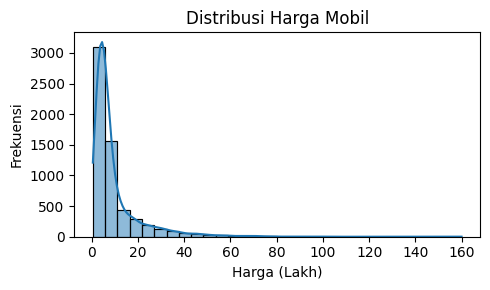

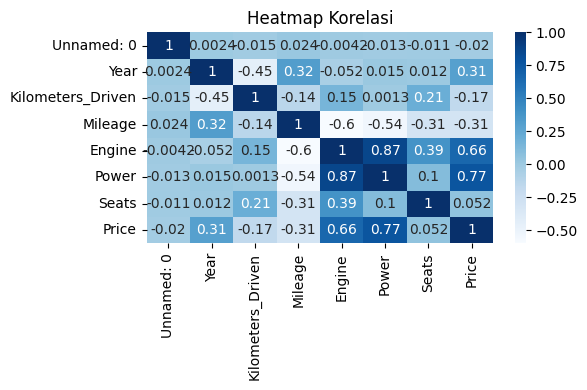

In [ ]:
# Distribusi harga mobil
plt.figure(figsize=(5,3))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Distribusi Harga Mobil')
plt.xlabel('Harga (Lakh)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Korelasi antar variabel numerik
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title('Heatmap Korelasi')
plt.tight_layout()
plt.show()

# penjelasan:
Grafik Distribusi Harga Mobil menunjukkan bahwa sebagian besar mobil memiliki harga di kisaran rendah, dan jumlahnya menurun seiring naiknya harga artinya data tidak merata dan cenderung ke harga rendah.

Sementara itu, Heatmap Korelasi menampilkan hubungan antar variabel numerik. Dari grafik terlihat bahwa Power, Engine, dan Year memiliki korelasi cukup tinggi dengan Price, yang berarti ketiga variabel tersebut berpengaruh besar terhadap harga mobil.

# CLEANING

In [ ]:
# Hapus duplikasi
df = df.drop_duplicates()

# Hapus baris dengan nilai kosong
df = df.dropna()

# Cek kembali
df.isnull().sum()

print("Jumlah data setelah cleaning:", df.shape)

Jumlah data setelah cleaning: (5582, 13)


# penjelasan:

Tahap ini dilakukan untuk membersihkan data.
Data yang duplikat dihapus menggunakan drop_duplicates(), sedangkan data yang memiliki nilai kosong dihapus dengan dropna().

In [ ]:
# Ubah kolom kategorik menjadi numerik
cat_cols = df.select_dtypes(include=['object']).columns
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

print("Kolom kategorikal yang diubah:", list(cat_cols))
df.head()

Kolom kategorikal yang diubah: ['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type']


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,0,1108,9,2010,72000.0,0,1,0,26.60,998.0,58.16,5.0,1.75
1,1,477,10,2015,41000.0,1,1,0,19.67,1582.0,126.20,5.0,12.50
2,2,451,2,2011,46000.0,3,1,0,18.20,1199.0,88.70,5.0,4.50
3,3,978,2,2012,87000.0,1,1,0,20.77,1248.0,88.76,7.0,6.00
4,4,20,3,2013,40670.0,1,0,2,15.20,1968.0,140.80,5.0,17.74


# penjelasan:

Beberapa kolom memiliki data berbentuk teks, sehingga perlu diubah menjadi angka agar bisa diproses lebih gampang.
Proses ini dilakukan menggunakan **LabelEncoder** pada setiap kolom bertipe object.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 5582 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         5582 non-null   int64  
 1   Name               5582 non-null   int64  
 2   Location           5582 non-null   int64  
 3   Year               5582 non-null   int64  
 4   Kilometers_Driven  5582 non-null   float64
 5   Fuel_Type          5582 non-null   int64  
 6   Transmission       5582 non-null   int64  
 7   Owner_Type         5582 non-null   int64  
 8   Mileage            5582 non-null   float64
 9   Engine             5582 non-null   float64
 10  Power              5582 non-null   float64
 11  Seats              5582 non-null   float64
 12  Price              5582 non-null   float64
dtypes: float64(6), int64(7)
memory usage: 610.5 KB


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
count,5582.000000,5582.000000,5582.00000,5582.000000,5582.000000,5582.000000,5582.000000,5582.000000,5582.000000,5582.000000,5582.000000,5582.000000,5582.000000
mean,3008.664099,852.603905,5.59674,2013.480831,57108.882121,1.896632,0.712290,0.365998,18.318047,1621.664815,112.901754,5.279470,9.566693
std,1739.447834,495.859720,2.95269,3.166113,37876.260778,1.008418,0.452736,0.805961,4.369031,601.183535,53.765286,0.799797,11.202026
min,0.000000,0.000000,0.00000,1998.000000,171.000000,0.000000,0.000000,0.000000,0.000000,624.000000,34.200000,2.000000,0.440000
25%,1503.250000,439.000000,3.00000,2012.000000,33312.000000,1.000000,0.000000,0.000000,15.300000,1198.000000,75.000000,5.000000,3.500000
50%,3011.500000,849.000000,5.00000,2014.000000,52465.500000,1.000000,1.000000,0.000000,18.490000,1494.000000,94.000000,5.000000,5.700000
75%,4511.750000,1222.750000,8.00000,2016.000000,72031.750000,3.000000,1.000000,0.000000,21.100000,1968.000000,138.100000,5.000000,10.000000
max,6018.000000,1754.000000,10.00000,2019.000000,775000.000000,3.000000,1.000000,3.000000,33.540000,5998.000000,560.000000,10.000000,160.000000


# penjelasan:

Cek ulang hasil akhir data setelah semua tahap preprocessing.
untuk memastikan tidak ada missing value, dll.

# DATA TRANSFORMATION

In [ ]:
# Pisahkan fitur dan target
X = df.drop(columns=['Price'])
y = df['Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Data scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

# penjelasan:

membangun model regresi linier untuk memprediksi harga mobil.
Urutan yang benar:

Pisahkan fitur (X) dan target (y)

Split data menjadi train dan test

Scaling data (StandardScaler)

Training model Linear Regression

In [ ]:
# Prediksi data uji
y_pred = model.predict(X_test_scaled)

# Hitung metrik evaluasi
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score  : {r2:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f}")


R² Score  : 0.6901
MAE       : 3.7516
MSE       : 37.9680
RMSE      : 6.1618


# penjelasan:

nilai R² yang didapatkan sebesar 0.69 yang artinya model mampu menjelaskan sekitar 69% variasi data asli. nilai MAE & RMSE tidak terlalu besar yang artinya menunjukan bahwa selisih antara hasil prediksi & data sebenarnya tergolong kecil.

In [ ]:
prediksi_df = pd.DataFrame({
    'Harga asli': y_test.values[:10],
    'Harga Prediksi': y_pred[:10]
})
prediksi_df

,Harga asli,Harga Prediksi
0,8.02,10.365648
1,8.25,9.197402
2,13.90,24.489510
3,1.50,-0.371781
4,3.99,12.353783
5,2.49,1.495944
6,5.25,4.917061
7,6.69,12.148039
8,2.65,0.961393
9,3.70,3.775955


# penjelasan

nemapilkan perbandingan antara harga asli & harga prediksi dari 10 data pertama hasil uji. untuk melihat apakah hasil prediksi model sudah mendekati nilai asli nya atau belum

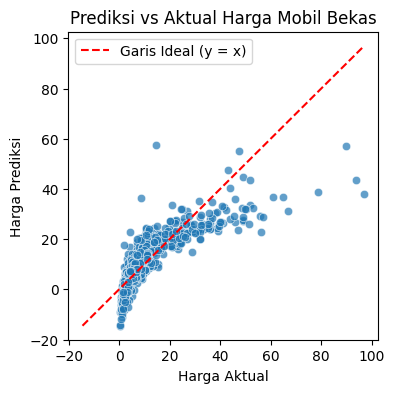

In [ ]:
plt.figure(figsize=(4,4))

# Scatter plot prediksi vs aktual
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)

# Tambahkan garis ideal (y = x)
max_value = max(max(y_test), max(y_pred))
min_value = min(min(y_test), min(y_pred))
plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--', label='Garis Ideal (y = x)')

# Label dan judul
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Prediksi vs Aktual Harga Mobil Bekas")
plt.legend()
plt.show()


# penjelasan:

Dari grafik terlihat sebagian besar titik sudah mengikuti arah garis merah (garis ideal), yang berarti hasil prediksi model cukup mendekati nilai sebenarnya. Namun, masih ada beberapa titik yang menyebar jauh dari garis, menandakan model belum sepenuhnya akurat dalam memprediksi harga mobil.